In [18]:
import os
import h5py
import numpy as np
import asf_search as asf
import earthaccess
import rioxarray
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from datetime import datetime
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("Imports OK")

Imports OK


---

## Helper functions

In [2]:
def parse_gunw_dates(scene_name):
    """
    Parse reference and secondary acquisition dates from a NISAR GUNW scene name.

    GUNW filenames encode four timestamps:
        ref_start, ref_stop, sec_start, sec_stop  (format: YYYYMMDDTHHMMSS)

    Example:
        NISAR_L2_PR_GUNW_008_077_A_138_009_4000_SH_
        20251221T135101_20251221T135136_  ← reference window
        20260102T135101_20260102T135136_  ← secondary window
        X05010_N_F_J_001

    Returns
    -------
    ref_date : str  YYYYMMDD
    sec_date : str  YYYYMMDD
    """
    parts = scene_name.split('_')
    timestamps = [p for p in parts if len(p) == 15 and 'T' in p]
    if len(timestamps) >= 4:
        return timestamps[0][:8], timestamps[2][:8]
    return None, None


def temporal_baseline(scene_name):
    """Return temporal baseline in days between reference and secondary passes."""
    ref, sec = parse_gunw_dates(scene_name)
    if ref and sec:
        return abs((datetime.strptime(sec, '%Y%m%d') -
                    datetime.strptime(ref, '%Y%m%d')).days)
    return None


def pct_limits(data, lo=2, hi=98):
    """Return percentile-based vmin/vmax, ignoring NaNs."""
    valid = data[np.isfinite(data)]
    if len(valid) == 0:
        return 0, 1
    return float(np.percentile(valid, lo)), float(np.percentile(valid, hi))


print("Helper functions defined.")

Helper functions defined.


---

## Search for the Granule

We can use `asf_search` to find the best granule for track 77, frame 138 (or any one of your choice).
`asf_search` supports precise InSAR-specific filters — track, frame, baseline — 
that `earthaccess` cannot provide because NISAR's CMR metadata lacks these attributes.

We then construct the HTTPS URL directly from the scene name,
which matches exactly what `asf_search` returns in `granule.properties['url']`.

In [5]:
# ─────────────────────────────────────────────
# SEARCH PARAMETERS (modify as needed)
# ─────────────────────────────────────────────
TRACK        = 77
FRAME        = 138
PRODUCT_TYPE = 'GUNW'
MAX_BASELINE = 12   # days: pick shortest baseline for best coherence

# ─────────────────────────────────────────────
print(f"Searching ASF for NISAR {PRODUCT_TYPE} · Track {TRACK} · Frame {FRAME}...")

results = asf.search(
    dataset        = 'NISAR',
    processingLevel= PRODUCT_TYPE,
    relativeOrbit  = TRACK,
    maxResults     = 500,
)
print("Search Finished.")

Searching ASF for NISAR GUNW · Track 77 · Frame 138...
Search Finished.


In [6]:
# Filter to target frame
frame_results = [
    r for r in results
    if r.properties.get('frameNumber') == FRAME
]
print(f"Frame {FRAME} granules found: {len(frame_results)}")

Frame 138 granules found: 6


In [8]:
# Sort by temporal baseline, pick shortest
frame_sorted = sorted(
    frame_results,
    key=lambda r: temporal_baseline(r.properties['sceneName']) or 999
)
granule  = frame_sorted[0]
p        = granule.properties
ref, sec = parse_gunw_dates(p['sceneName'])
bl       = temporal_baseline(p['sceneName'])
ref_fmt  = f"{ref[:4]}-{ref[4:6]}-{ref[6:]}"
sec_fmt  = f"{sec[:4]}-{sec[4:6]}-{sec[6:]}"

# HTTPS URL — constructed directly from scene name
# Pattern: {base}/{scene_name}/{scene_name}.h5
BASE_URL   = 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GUNW_BETA_V1'
scene_name = p['sceneName']
https_url  = f"{BASE_URL}/{scene_name}/{scene_name}.h5"

# Verify URL matches asf_search
assert https_url == p['url'], "URL mismatch — check scene name pattern"

print(f"\nSelected granule:")
print(f"  Scene      : {scene_name}")
print(f"  Track      : {p.get('pathNumber')}  (fixed ground path, repeated every 12 days)")
print(f"  Frame      : {p.get('frameNumber')}  (spatial tile along the track)")
print(f"  Direction  : {p.get('flightDirection')}  (satellite flying S→N, looking west)")
print(f"  Reference  : {ref_fmt}")
print(f"  Secondary  : {sec_fmt}")
print(f"  Baseline   : {bl} days")
print(f"  Bandwidth  : {p.get('rangeBandwidth')} MHz")
print(f"  Coverage   : {p.get('frameCoverage')}")
print(f"  File size  : {p.get('bytes',{}).get(p.get('fileName',''),{}).get('bytes',0)/1e9:.2f} GB")
print(f"  HTTPS URL  : {https_url[:80]}...")


Selected granule:
  Scene      : NISAR_L2_PR_GUNW_008_077_A_138_009_4000_SH_20251221T135101_20251221T135136_20260102T135101_20260102T135136_X05010_N_F_J_001
  Track      : 77  (fixed ground path, repeated every 12 days)
  Frame      : 138  (spatial tile along the track)
  Direction  : ASCENDING  (satellite flying S→N, looking west)
  Reference  : 2025-12-21
  Secondary  : 2026-01-02
  Baseline   : 12 days
  Bandwidth  : ['40'] MHz
  Coverage   : Full
  File size  : 2.36 GB
  HTTPS URL  : https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GUNW_BETA_V1/NISAR_L2_P...


---

## Authenticate & Open HTTPS Stream

We use `earthaccess` purely for authentication, it manages the NASA Earthdata
login and provides an authenticated `fsspec` HTTPS session.

### Why HTTPS and not S3?
NISAR data lives in AWS S3 `us-west-2` (Oregon). Direct S3 access is only available
for compute resources **inside** AWS `us-west-2`. From a local machine anywhere else
(including Idaho), S3 returns 403 Forbidden by design. HTTPS via CloudFront works
from anywhere and is the correct protocol for local workflows.

Reference: https://nisar-docs.asf.alaska.edu/aws-s3-access/#s3-access-limitations

In [9]:
# Login — uses .netrc if configured, otherwise prompts for credentials
# Create a free account at: https://urs.earthdata.nasa.gov
auth = earthaccess.login()
print(f"Authenticated: {auth.authenticated}")

Authenticated: True


In [10]:
# Open HTTPS stream
# fsspec opens a connection — no data transferred yet
# Data only moves when we read a specific dataset with [:]
fsspec_config = {
    'cache_type': 'background',
    'block_size': 16 * 1024 * 1024,  # 16 MB read-ahead blocks
}

fs = earthaccess.get_fsspec_https_session()

print(f"Opening HTTPS stream (no data transferred yet)...")
hf = h5py.File(
    fs.open(https_url, **fsspec_config),
    'r'
)
print(f"✓ Stream open. Top-level groups: {list(hf.keys())}")

Opening HTTPS stream (no data transferred yet)...
✓ Stream open. Top-level groups: ['complex64', 'science']


---

## Explore the HDF5 Structure

Walk the file tree to confirm the actual layer paths.
Run this once, comment it out on subsequent runs.

In [11]:
def print_hdf5_tree(hf, max_depth=5, _path='', _depth=0):
    """Recursively print HDF5 groups and datasets."""
    for key in hf.keys():
        item   = hf[key]
        indent = '  ' * _depth
        if isinstance(item, h5py.Dataset):
            print(f"{indent}📄 {key}  {item.shape}  {item.dtype}")
        else:
            print(f"{indent}📁 {key}/")
            if _depth < max_depth:
                print_hdf5_tree(item, max_depth, f"{_path}/{key}", _depth + 1)

print("NISAR GUNW HDF5 structure (grids):")
print("=" * 55)
print_hdf5_tree(hf['science']['LSAR']['GUNW']['grids'])

NISAR GUNW HDF5 structure (grids):
📁 frequencyA/
  📄 centerFrequency  ()  float64
  📄 listOfPolarizations  (1,)  |S2
  📁 pixelOffsets/
    📁 HH/
      📄 alongTrackOffset  (4716, 4635)  float32
      📄 correlationSurfacePeak  (4716, 4635)  float32
      📄 projection  ()  uint32
      📄 slantRangeOffset  (4716, 4635)  float32
      📄 xCoordinateSpacing  ()  float64
      📄 xCoordinates  (4635,)  float64
      📄 yCoordinateSpacing  ()  float64
      📄 yCoordinates  (4716,)  float64
    📄 mask  (4716, 4635)  uint8
    📄 projection  ()  uint32
    📄 xCoordinateSpacing  ()  float64
    📄 xCoordinates  (4635,)  float64
    📄 yCoordinateSpacing  ()  float64
    📄 yCoordinates  (4716,)  float64
  📁 unwrappedInterferogram/
    📁 HH/
      📄 coherenceMagnitude  (4716, 4635)  float32
      📄 connectedComponents  (4716, 4635)  uint16
      📄 ionospherePhaseScreen  (4716, 4635)  float32
      📄 ionospherePhaseScreenUncertainty  (4716, 4635)  float32
      📄 projection  ()  uint32
      📄 unwrappedPh

---

## Read Coordinate Arrays

GUNW products are geocoded in **UTM** (Universal Transverse Mercator).
There are three grids at different resolutions:

| Grid group | Resolution | Shape |
|---|---|---|
| `wrappedInterferogram` | ~5m | (18864, 18540) |
| `unwrappedInterferogram` | ~20m | (4716, 4635) |
| `metadata/radarGrid` | coarse | (767, 754) |

Each resolution has its own coordinate arrays, we read them all.

In [12]:
BASE_GRIDS = 'science/LSAR/GUNW/grids/frequencyA'
BASE_META  = 'science/LSAR/GUNW/metadata'

# ── 5m grid (wrapped interferogram) ──
x_5m  = hf[f'{BASE_GRIDS}/wrappedInterferogram/HH/xCoordinates'][:]
y_5m  = hf[f'{BASE_GRIDS}/wrappedInterferogram/HH/yCoordinates'][:]
dx_5m = float(hf[f'{BASE_GRIDS}/wrappedInterferogram/HH/xCoordinateSpacing'][()])
dy_5m = float(hf[f'{BASE_GRIDS}/wrappedInterferogram/HH/yCoordinateSpacing'][()])

# ── 20m grid (unwrapped interferogram) ──
x_20m  = hf[f'{BASE_GRIDS}/unwrappedInterferogram/HH/xCoordinates'][:]
y_20m  = hf[f'{BASE_GRIDS}/unwrappedInterferogram/HH/yCoordinates'][:]
dx_20m = float(hf[f'{BASE_GRIDS}/unwrappedInterferogram/HH/xCoordinateSpacing'][()])
dy_20m = float(hf[f'{BASE_GRIDS}/unwrappedInterferogram/HH/yCoordinateSpacing'][()])

# ── Coarse grid (incidence angle) ──
x_inc  = hf[f'{BASE_META}/radarGrid/xCoordinates'][:]
y_inc  = hf[f'{BASE_META}/radarGrid/yCoordinates'][:]

# ── Read EPSG projection code ──
epsg = int(hf[f'{BASE_GRIDS}/unwrappedInterferogram/HH/projection'][()])

print(f"Projection  : EPSG:{epsg}")
print(f"5m  grid    : {len(x_5m)} cols × {len(y_5m)} rows  |  spacing: {dx_5m:.1f} × {dy_5m:.1f} m")
print(f"20m grid    : {len(x_20m)} cols × {len(y_20m)} rows  |  spacing: {dx_20m:.1f} × {dy_20m:.1f} m")
print(f"Coarse grid : {len(x_inc)} cols × {len(y_inc)} rows")
print(f"Easting     : {x_20m.min():.0f} → {x_20m.max():.0f} m")
print(f"Northing    : {y_20m.min():.0f} → {y_20m.max():.0f} m")
print(f"Width       : {(x_20m.max()-x_20m.min())/1000:.1f} km")
print(f"Height      : {abs(y_20m.max()-y_20m.min())/1000:.1f} km")

Projection  : EPSG:3031
5m  grid    : 18540 cols × 18864 rows  |  spacing: 20.0 × -20.0 m
20m grid    : 4635 cols × 4716 rows  |  spacing: 80.0 × -80.0 m
Coarse grid : 754 cols × 767 rows
Easting     : -1273640 → -902920 m
Northing    : -387320 → -10120 m
Width       : 370.7 km
Height      : 377.2 km


---

## Stream & Read All Layers

This is where data actually transfers from NASA's servers to your RAM.
Only the datasets we request are fetched, not the full 2.36 GB file.

In [17]:
def read_masked(ds_path, fill_zero=True):
    """
    Read an HDF5 dataset and mask fill values and optionally zeros.
    Zeros are common no-data indicators in NISAR products.
    """
    ds   = hf[ds_path]
    data = ds[:].astype(np.float32)
    fv   = ds.attrs.get('_FillValue', None)
    if fv is not None:
        data = np.where(data == fv, np.nan, data)
    if fill_zero:
        data[data == 0] = np.nan
    return data


# ── Important distinction ──────────────────────────────────────────────────
# Disk size vs RAM footprint are NOT the same thing.
#
# The HDF5 file on NASA's server is 2.36 GB ON DISK, that is the compressed
# size. HDF5 stores data in compressed chunks.
#
# When you read a dataset with hf[path][:], h5py:
#   1. Fetches the compressed chunks (over network if streaming, from disk if local)
#   2. Decompresses them
#   3. Returns a full uncompressed numpy array into RAM
#
# So RAM footprint = rows × cols × bytes_per_element  (uncompressed)
#    Disk size     = compressed HDF5 file             (2.36 GB)
#
# These are independent. Reading from a local file gives the SAME RAM footprint
# as streaming — the only difference is network transfer vs disk I/O.
# ──────────────────────────────────────────────────────────────────────────

print("Reading 20m layers only (skipping 5m layers for speed)...")
print("Note: sizes shown are actual RAM footprints after decompression.\n")

# ── 1. Unwrapped phase (20m) ──
print("  1/3  Unwrapped phase...")
unwrapped = read_masked(f'{BASE_GRIDS}/unwrappedInterferogram/HH/unwrappedPhase')
print(f"     Shape : {unwrapped.shape}  dtype: {unwrapped.dtype}")
print(f"     Range : {np.nanmin(unwrapped):.2f} – {np.nanmax(unwrapped):.2f} rad")

# ── 2. Coherence 20m ──
print("  2/3  Coherence 20m...")
coherence_20m = read_masked(f'{BASE_GRIDS}/unwrappedInterferogram/HH/coherenceMagnitude')
print(f"     Shape : {coherence_20m.shape}  dtype: {coherence_20m.dtype}")
print(f"     Range : {np.nanmin(coherence_20m):.3f} – {np.nanmax(coherence_20m):.3f}")

# ── 3. Incidence angle ──
print("  3/3  Incidence angle...")
heights      = hf[f'{BASE_META}/radarGrid/heightAboveEllipsoid'][:]
ground_idx   = int(np.argmin(np.abs(heights)))
incidence    = hf[f'{BASE_META}/radarGrid/incidenceAngle'][ground_idx].astype(np.float32)
incidence[incidence == 0] = np.nan
print(f"     Shape : {incidence.shape}  dtype: {incidence.dtype}")
print(f"     Range : {np.nanmin(incidence):.2f}° – {np.nanmax(incidence):.2f}°")
print(f"     Using height layer index {ground_idx} ({heights[ground_idx]:.0f} m)")


# ── Actual RAM footprint summary ──
layers = {
    'unwrapped_phase' : unwrapped,
    'coherence_20m'   : coherence_20m,
    'incidence_angle' : incidence,
}
total_bytes = sum(a.nbytes for a in layers.values())
print(f"\n── RAM Footprint Summary ─────────────────────────────")
print(f"  {'Layer':<25} {'Shape':<18} {'RAM'}")
print(f"  {'-'*55}")
for name, arr in layers.items():
    mb = arr.nbytes / 1e6
    print(f"  {name:<25} {str(arr.shape):<18} {mb:.1f} MB")
print(f"  {'-'*55}")
print(f"  {'Total in RAM':<25} {'':18} {total_bytes/1e6:.1f} MB")
print(f"""
  ── What we saved and what we didn't ──────────────────
  Disk space saved : ~2,357 MB  — the full HDF5 was never
                                  written to disk
  RAM saved        : none       — RAM footprint depends on
                                  which layers you read,
                                  not on streaming vs local

  Note: reading the same 3 layers from a local HDF5 file
  would use the exact same {total_bytes/1e6:.0f} MB of RAM.
  Streaming does not reduce RAM, it reduces disk usage.
""")
print(f"✓ Done. Ready to plot.")

Reading 20m layers only (skipping 5m layers for speed)...
Note: sizes shown are actual RAM footprints after decompression.

  1/3  Unwrapped phase...
     Shape : (4716, 4635)  dtype: float32
     Range : -12.89 – 20.94 rad
  2/3  Coherence 20m...
     Shape : (4716, 4635)  dtype: float32
     Range : 0.003 – 0.888
  3/3  Incidence angle...
     Shape : (767, 754)  dtype: float32
     Range : 25.38° – 53.18°
     Using height layer index 1 (0 m)

── RAM Footprint Summary ─────────────────────────────
  Layer                     Shape              RAM
  -------------------------------------------------------
  unwrapped_phase           (4716, 4635)       87.4 MB
  coherence_20m             (4716, 4635)       87.4 MB
  incidence_angle           (767, 754)         2.3 MB
  -------------------------------------------------------
  Total in RAM                                 177.2 MB

  ── What we saved and what we didn't ──────────────────
  Disk space saved : ~2,357 MB  — the full HDF5 w

---

## Export to GeoTIFF

We use `rioxarray` to attach the UTM CRS and spatial transform to each layer,
then export as GeoTIFF. GeoTIFFs are:
- Immediately usable in QGIS, ArcGIS, or any GIS tool
- Self-describing: CRS and extent are embedded in the file
- Shareable with colleagues without needing Python
- Expected to be much smaller than the full HDF5 (only the layers you need)

### What is rioxarray?
`rioxarray` extends `xarray` with geospatial awareness. It understands CRS,
spatial transforms, and can read/write GeoTIFF format via `rasterio`.

In [19]:
# Output directory
OUT_DIR = Path(f'./nisar_geotiff/track{TRACK}_frame{FRAME}_{ref}_{sec}')
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUT_DIR}")


def make_da(data, x_coords, y_coords, name, long_name, units, epsg_code):
    """
    Wrap a 2D numpy array in a georeferenced xarray.DataArray.

    Parameters
    ----------
    data      : 2D numpy array
    x_coords  : 1D array of easting coordinates (UTM metres)
    y_coords  : 1D array of northing coordinates (UTM metres)
    name      : short variable name
    long_name : descriptive name
    units     : physical units string
    epsg_code : integer EPSG code (e.g. 32611 for UTM zone 11N)
    """
    da = xr.DataArray(
        data,
        dims   = ['y', 'x'],
        coords = {'x': x_coords, 'y': y_coords},
        name   = name,
        attrs  = {'long_name': long_name, 'units': units}
    )
    da = da.rio.write_crs(f'EPSG:{epsg_code}')
    da = da.rio.write_nodata(np.nan)
    return da


def export_geotiff(da, filename, description=''):
    """Save a DataArray as a GeoTIFF and print file info."""
    path = OUT_DIR / filename
    da.rio.to_raster(str(path), driver='GTiff', dtype='float32',
                     compress='deflate')
    size_mb = path.stat().st_size / 1e6
    print(f"  ✓ {filename:<50} {size_mb:6.1f} MB  {description}")
    return path


print("\nExporting 20m layers to GeoTIFF...")
print(f"  {'Filename':<50} {'Disk size':>10}  Description")
print("  " + "-" * 80)

# ── 1. Unwrapped phase ──
da_unwrap = make_da(unwrapped, x_20m, y_20m,
                    'unwrapped_phase', 'Unwrapped interferometric phase', 'radians', epsg)
export_geotiff(da_unwrap, 'unwrapped_phase.tif', '20m · primary deformation signal')

# ── 2. Coherence 20m ──
da_coh20 = make_da(coherence_20m, x_20m, y_20m,
                   'coherence_20m', 'Interferometric coherence magnitude', '0-1', epsg)
export_geotiff(da_coh20, 'coherence_20m.tif', '20m · phase quality mask')

# ── 3. Incidence angle ──
da_inc = make_da(incidence, x_inc, y_inc,
                 'incidence_angle', 'Radar incidence angle', 'degrees', epsg)
export_geotiff(da_inc, 'incidence_angle.tif', 'coarse · radar look angle')


# ── Summary ──
tif_files   = sorted(OUT_DIR.glob('*.tif'))
total_tif_mb = sum(f.stat().st_size for f in tif_files) / 1e6
hdf5_mb      = p.get('bytes',{}).get(p.get('fileName',''),{}).get('bytes',0) / 1e6

print(f"""
  ── Disk Usage Summary ────────────────────────────────
  GeoTIFFs exported (compressed, on disk) : {total_tif_mb:.0f} MB
  Full HDF5 on disk (compressed)          : {hdf5_mb:.0f} MB
  Disk space saved                        : {100*(1 - total_tif_mb/hdf5_mb):.0f}%

  Note: disk sizes are compressed. RAM footprint when
  reading these GeoTIFFs will be larger (uncompressed).
  Reading the same layers from the original HDF5 locally
  would use the same RAM as reading from these GeoTIFFs.
""")
print(f"✓ Export complete. Files saved to: {OUT_DIR}")

Output directory: nisar_geotiff/track77_frame138_20251221_20260102

Exporting 20m layers to GeoTIFF...
  Filename                                            Disk size  Description
  --------------------------------------------------------------------------------
  ✓ unwrapped_phase.tif                                  32.1 MB  20m · primary deformation signal
  ✓ coherence_20m.tif                                    31.3 MB  20m · phase quality mask
  ✓ incidence_angle.tif                                   1.9 MB  coarse · radar look angle

  ── Disk Usage Summary ────────────────────────────────
  GeoTIFFs exported (compressed, on disk) : 65 MB
  Full HDF5 on disk (compressed)          : 2357 MB
  Disk space saved                        : 97%

  Note: disk sizes are compressed. RAM footprint when
  reading these GeoTIFFs will be larger (uncompressed).
  Reading the same layers from the original HDF5 locally
  would use the same RAM as reading from these GeoTIFFs.

✓ Export complete. Fi

---

## 12. Let's Plot

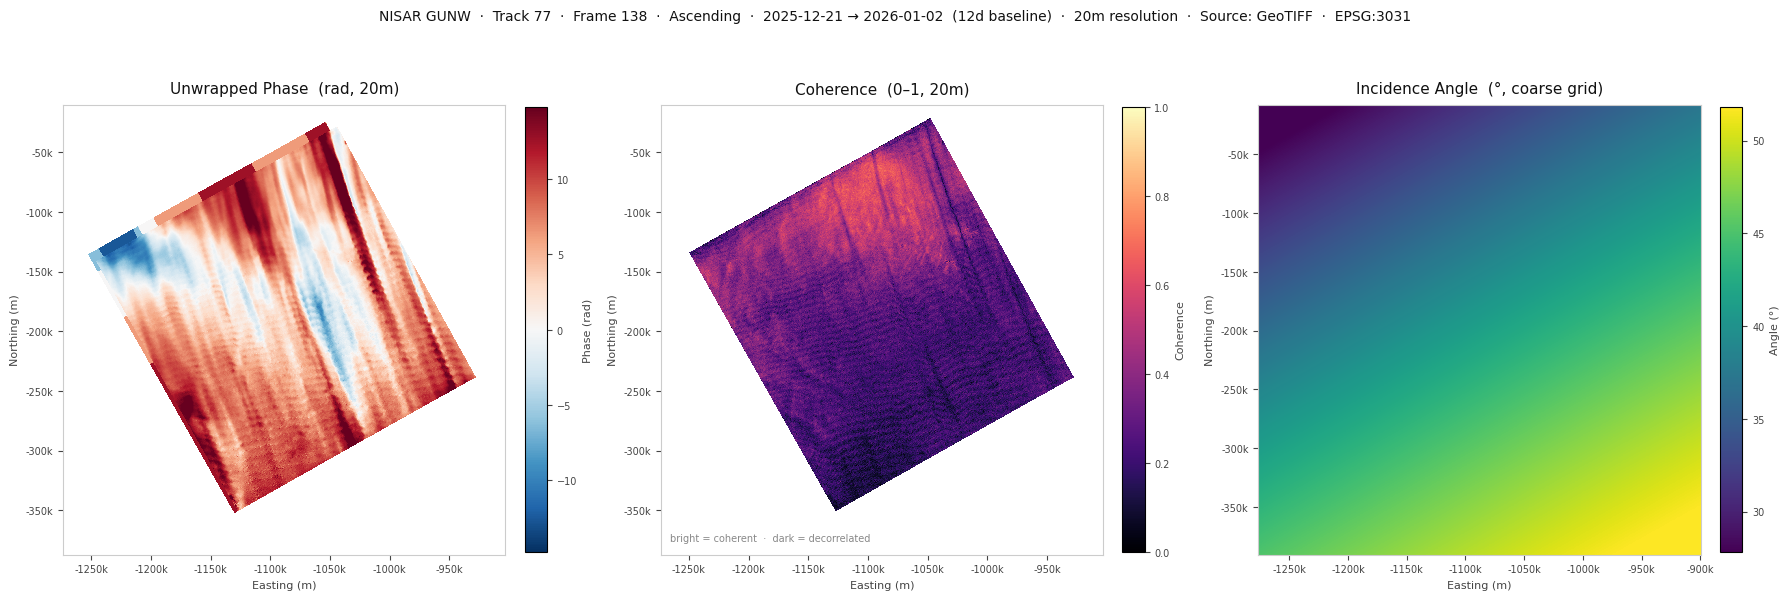

Saved: nisar_geotiff/track77_frame138_20251221_20260102/nisar_gunw_track77_frame138_20251221_20260102_20m.png


In [22]:
# Read GeoTIFFs back
tif_unwrap = rioxarray.open_rasterio(OUT_DIR / 'unwrapped_phase.tif',  masked=True).squeeze()
tif_coh    = rioxarray.open_rasterio(OUT_DIR / 'coherence_20m.tif',    masked=True).squeeze()
tif_inc    = rioxarray.open_rasterio(OUT_DIR / 'incidence_angle.tif',  masked=True).squeeze()

unwrap_plot = tif_unwrap.values
coh_plot    = tif_coh.values
inc_plot    = tif_inc.values

def extent_from_da(da):
    return [da.x.values.min(), da.x.values.max(),
            da.y.values.min(), da.y.values.max()]

ext_20m = extent_from_da(tif_unwrap)
ext_inc = extent_from_da(tif_inc)

# ── 3-panel figure ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# fig.patch.set_facecolor('#0d0d0d')
fig.patch.set_facecolor('white')

imkw = dict(origin='upper', aspect='equal', interpolation='nearest')

def style_ax(ax, title):
    ax.set_facecolor('white')
    ax.set_title(title, color='#111111', fontsize=11, fontweight='normal', pad=8)
    ax.set_xlabel('Easting (m)', color='#444444', fontsize=8)
    ax.set_ylabel('Northing (m)', color='#444444', fontsize=8)
    ax.tick_params(colors='#444444', labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y/1e3:.0f}k'))


def add_cbar(fig, im, ax, label):
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(label, color='#444444', fontsize=8)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='#444444')
    cb.ax.yaxis.set_tick_params(color='#444444', labelsize=7)

# ── Panel 1: Unwrapped phase ──
ax = axes[0]
vmin, vmax = pct_limits(unwrap_plot)
lim = max(abs(vmin), abs(vmax))
im = ax.imshow(unwrap_plot, extent=ext_20m, cmap='RdBu_r',
               vmin=-lim, vmax=lim, **imkw)
style_ax(ax, 'Unwrapped Phase  (rad, 20m)')
add_cbar(fig, im, ax, 'Phase (rad)')

# ── Panel 2: Coherence ──
ax = axes[1]
im = ax.imshow(coh_plot, extent=ext_20m, cmap='magma',
               vmin=0, vmax=1, **imkw)
style_ax(ax, 'Coherence  (0–1, 20m)')
add_cbar(fig, im, ax, 'Coherence')
ax.text(0.02, 0.03, 'bright = coherent  ·  dark = decorrelated',
        transform=ax.transAxes, color='#888888', fontsize=7)

# ── Panel 3: Incidence angle ──
ax = axes[2]
vmin, vmax = pct_limits(inc_plot, lo=1, hi=99)
im = ax.imshow(inc_plot, extent=ext_inc, cmap='viridis',
               vmin=vmin, vmax=vmax, **imkw)
style_ax(ax, 'Incidence Angle  (°, coarse grid)')
add_cbar(fig, im, ax, 'Angle (°)')

fig.suptitle(
    f'NISAR GUNW  ·  Track {TRACK}  ·  Frame {FRAME}  ·  Ascending  ·  '
    f'{ref_fmt} → {sec_fmt}  ({bl}d baseline)  ·  20m resolution  ·  '
    f'Source: GeoTIFF  ·  EPSG:{epsg}',
    color='#111111', fontsize=10, y=1.01
)

plt.tight_layout()
out_fig = OUT_DIR / f'nisar_gunw_track{TRACK}_frame{FRAME}_{ref}_{sec}_20m.png'
plt.savefig(str(out_fig), dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out_fig}")